In [1]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
# Cell 2: Load Iris dataset with proper column names
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

# Load the CSV with column names
df = pd.read_csv("iris.csv", names=column_names)

# Show first few rows
print("First 5 rows of Iris dataset:")
print(df.head())

print("\n" + "="*50)
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows of Iris dataset:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Dataset shape: (150, 5)

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [15]:
# Cell 3: Check data structure
print("="*50)
print("DATASET INFORMATION")
print("="*50)

print("\nColumn Names and Data Types:")
print("-"*30)
df.info()

print("\nBasic Statistics:")
print("-"*30)
df.describe()

DATASET INFORMATION

Column Names and Data Types:
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Basic Statistics:
------------------------------


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [16]:
# Cell 4: Check for missing values
print("="*50)
print("MISSING VALUES CHECK")
print("="*50)

missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

MISSING VALUES CHECK
Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [17]:
# Cell 5: Check for duplicate rows
print("="*50)
print("DUPLICATE ROWS CHECK")
print("="*50)

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

DUPLICATE ROWS CHECK
Number of duplicate rows: 3


SPECIES DISTRIBUTION
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


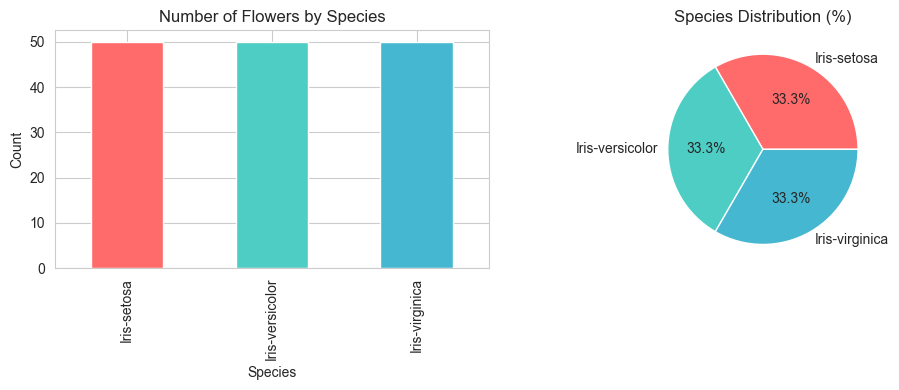

In [18]:
# Cell 6: Species distribution
print("="*50)
print("SPECIES DISTRIBUTION")
print("="*50)

species_counts = df['species'].value_counts()
print(species_counts)

# Visualize
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
species_counts.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Number of Flowers by Species')
plt.xlabel('Species')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.pie(species_counts.values, labels=species_counts.index, autopct='%1.1f%%',
        colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Species Distribution (%)')

plt.tight_layout()
plt.show()

MEASUREMENT DISTRIBUTIONS


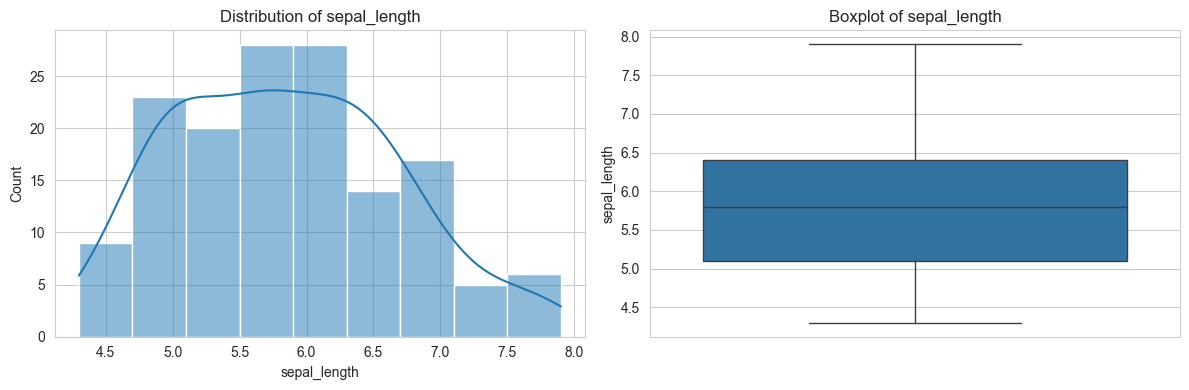


Statistics for sepal_length:
Mean: 5.84
Median: 5.80
Min: 4.30
Max: 7.90
------------------------------


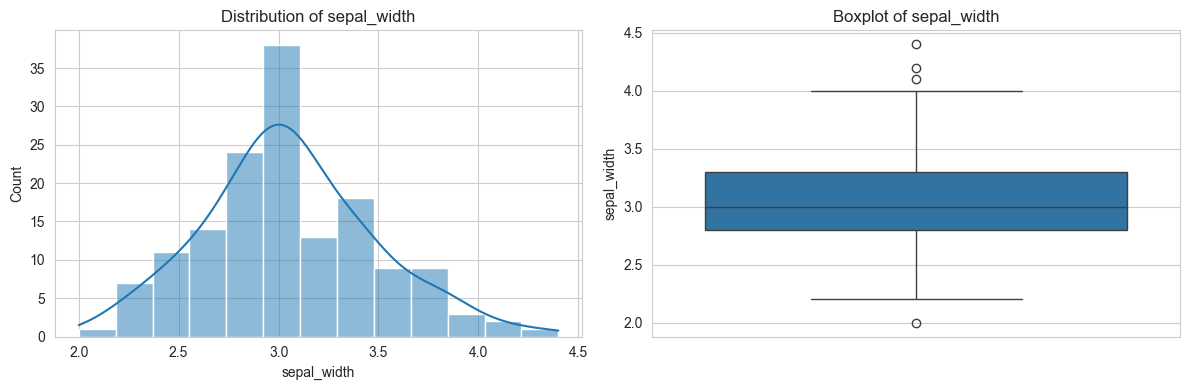


Statistics for sepal_width:
Mean: 3.05
Median: 3.00
Min: 2.00
Max: 4.40
------------------------------


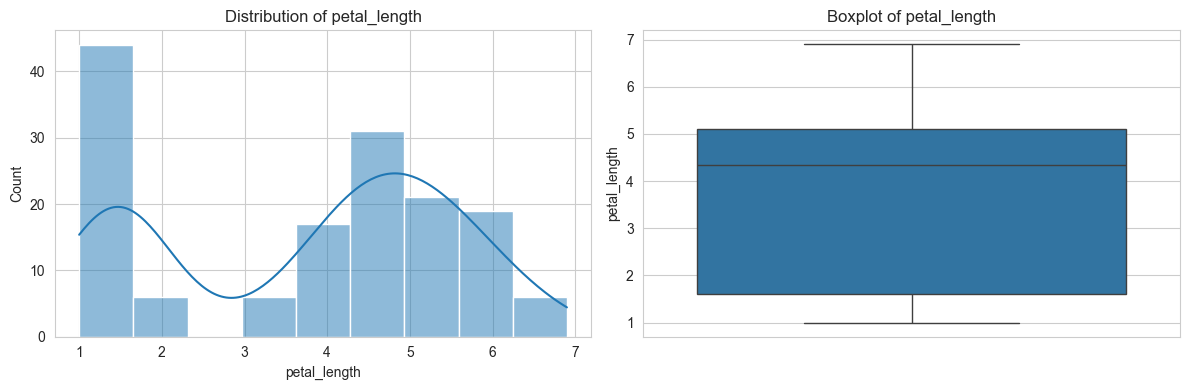


Statistics for petal_length:
Mean: 3.76
Median: 4.35
Min: 1.00
Max: 6.90
------------------------------


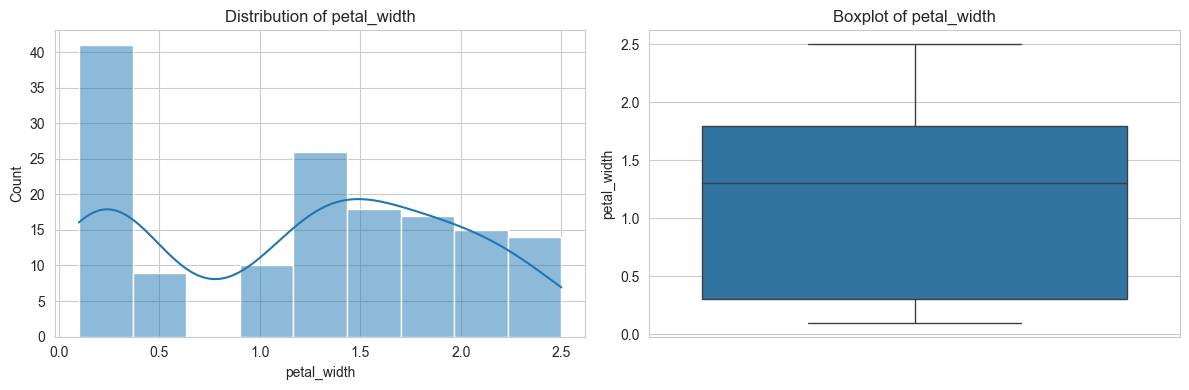


Statistics for petal_width:
Mean: 1.20
Median: 1.30
Min: 0.10
Max: 2.50
------------------------------


In [19]:
# Cell 7: Distribution of each measurement
print("="*50)
print("MEASUREMENT DISTRIBUTIONS")
print("="*50)

measurement_cols = [col for col in df.columns if col != 'species']

for col in measurement_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    
    # Boxplot
    sns.boxplot(data=df, y=col, ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nStatistics for {col}:")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")
    print("-"*30)

In [ ]:
# Cell 10: Summarize findings
print("="*60)
print("KEY INSIGHTS FROM IRIS DATASET")
print("="*60)

# Insight 1: Dataset quality
print("\n DATA QUALITY:")
print(f"• Dataset has {df.shape[0]} iris flowers, each with {df.shape[1]-1} measurements")
print(f"• No missing values found - dataset is clean")
print(f"• {len(species_counts)} species: {', '.join(species_counts.index)}")

# Insight 2: Species distribution
print(f"\n SPECIES BALANCE:")
for species, count in species_counts.items():
    percentage = (count/len(df))*100
    print(f"• {species}: {count} samples ({percentage:.1f}%)")

# Insight 3: Key distinguishing features
print("\n KEY FINDINGS:")
print("• Setosa is the most distinct species - it has:")
print("  - Much smaller petals than the others")
print("  - Wider sepals compared to its petal size")
print("\n• Versicolor and Virginica are more similar, but Virginica tends to be larger")
print("  in all measurements")

# Insight 4: Classification insight
print(f"\n CLASSIFICATION INSIGHT:")
print("• Setosa can be identified by petal measurements alone")
print("• Versicolor and Virginica need both petal and sepal measurements to distinguish")

KEY INSIGHTS FROM IRIS DATASET

📊 DATA QUALITY:
• Dataset has 150 iris flowers, each with 4 measurements
• No missing values found - dataset is clean
• 3 species: Iris-setosa, Iris-versicolor, Iris-virginica

🌸 SPECIES BALANCE:
• Iris-setosa: 50 samples (33.3%)
• Iris-versicolor: 50 samples (33.3%)
• Iris-virginica: 50 samples (33.3%)

🔍 KEY FINDINGS:
• Setosa is the most distinct species - it has:
  - Much smaller petals than the others
  - Wider sepals compared to its petal size

• Versicolor and Virginica are more similar, but Virginica tends to be larger
  in all measurements

🎯 CLASSIFICATION INSIGHT:
• Setosa can be identified by petal measurements alone
• Versicolor and Virginica need both petal and sepal measurements to distinguish
